### BUSINESS UNDERSTANDING   

Digital payments are evolving, but so are cyber criminals.

According to the Data Breach Index, more than 5 million records are being stolen on a daily basis, a concerning statistic that shows - fraud is still very common both for Card-Present and Card-not Present type of payments.

In today’s digital world where trillions of Card transaction happens per day, detection of fraud is challenging.

These notebooks attempt to provide machine learning and artificial intelligence models to detect fraudulent credit card transactions.




### DATA UNDERSTANDING

A sample of 30,000 rows is obtained from the Credit Card Transactions Dataset that comes from Kaggle.

The dataset provides detailed records of credit card transactions, including information about transaction times, amounts, and associated personal and merchant details.

The dataset can be used in the following ways:

Fraud Detection : Use machine learning models to identify fraudulent transactions by examining patterns in transaction amounts, locations, and user profiles. Enhancing fraud detection systems becomes feasible by analyzing behavioral patterns.

Customer Segmentation : Segment customers based on spending patterns, location, and demographics. Tailor marketing strategies and personalized offers to these different customer segments for better engagement.

Transaction Classification : Classify transactions into categories such as grocery or entertainment to understand spending behaviors. This helps in improving recommendation systems by identifying transaction categories and preferences.

Geospatial Analysis : Analyze transaction data geographically to map spending patterns and detect regional trends or anomalies based on latitude and longitude.

Predictive Modeling : Build models to forecast future spending behavior using historical transaction data. Predict potential fraudulent activities and financial trends.

Behavioral Analysis : Examine how factors like transaction amount, merchant type, and time influence spending behavior. Study the relationships between user demographics and transaction patterns.

Anomaly Detection : Identify unusual transaction patterns that deviate from normal behavior to detect potential fraud early. Employ anomaly detection techniques to spot outliers and suspicious activities.


**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')


**Load sample dataset**

In [2]:
df = pd.read_csv('sample_30000A.csv')

In [3]:
# Check the number of rows and columns
df.shape

(30000, 24)

In [4]:
# Verify sample dataset
df.head().T

,0,1,2,3,4
index_col,17974,57707,132617,174212,60350
trans_date_time,2019-01-11 19:47:34,2019-02-04 02:37:51,2019-03-14 07:56:28,2019-04-01 08:31:04,2019-02-05 05:37:34
cc_num,30551643947183,5388659976630693,213161293389774,4952583804639909,4822367783500458
merchant,fraud_Schmidt-Larkin,"fraud_Lind, Huel and McClure","fraud_Terry, Johns and Bins","fraud_Haley, Jewess and Bechtelar",fraud_Hudson-Ratke
category,home,gas_transport,misc_pos,shopping_pos,grocery_pos
amt,60.64,62.74,1.3,6.85,55.82
first_name,Morgan,Charles,Catherine,Patricia,Christopher
last_name,Smith,Preston,Weber,Rodriguez,Farrell
gender,F,M,F,F,M
street,1441 Bradley Place,5364 William Harbor,74890 Rodriguez Springs Apt. 540,386 Randolph Throughway,97070 Anderson Land


In [5]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index_col        30000 non-null  int64  
 1   trans_date_time  30000 non-null  object 
 2   cc_num           30000 non-null  int64  
 3   merchant         30000 non-null  object 
 4   category         30000 non-null  object 
 5   amt              30000 non-null  float64
 6   first_name       30000 non-null  object 
 7   last_name        30000 non-null  object 
 8   gender           30000 non-null  object 
 9   street           30000 non-null  object 
 10  city             30000 non-null  object 
 11  state            30000 non-null  object 
 12  zip              30000 non-null  float64
 13  lat              30000 non-null  float64
 14  long             30000 non-null  float64
 15  city_pop         30000 non-null  float64
 16  job              30000 non-null  object 
 17  dob         

### DATA PREPARATION     

Leading and trailing white spaces are removed from categorical columns. Any duplicates are verified.    

The missing values in the column 'merch_zipcode' are not imputed to preserve any fraud signals from these missing values.     

Data is cleaned and data types assigned as required.

Feature engineering included the following:
1. user zip codes are regionalized to reduce cardinality
2. time since last purchase is calculated using 'unix_time'
3. the amount of deviation from the average transactions is found
4. the distance of the user from the merchant is calculated
5. the transaction velocity in miles per hour is computed
6. age is determined from the 'dob'
7. hour is expressed in terms of the sine and cosine functions
8. the frequency of merchant transactions is determined
9. 'missing_merch_zip' feature is created from the 'merch_zipcode' missing values

Fraud signals are analyzed using box plots, histograms, stacked bar plots, heat maps and pair plots as well as other visualization techniques like scatter plots and bar charts.

In [6]:
# Remove any leading and trailing white spaces from categorical columns
string_cols = df.select_dtypes(include=['object']).columns
df[string_cols] = df[string_cols].apply(lambda x: x.str.strip())

In [7]:
# Verify duplicates, if any
duplicates = len(df[df.duplicated()])

print(f'There are {duplicates} duplicate rows.')

There are 0 duplicate rows.


In [8]:
# Verify the total missing values
total_missing_values = df.isnull().sum().sum()  # count the total number of missing values

print(f'There are {total_missing_values} total missing values.')

There are 4606 total missing values.


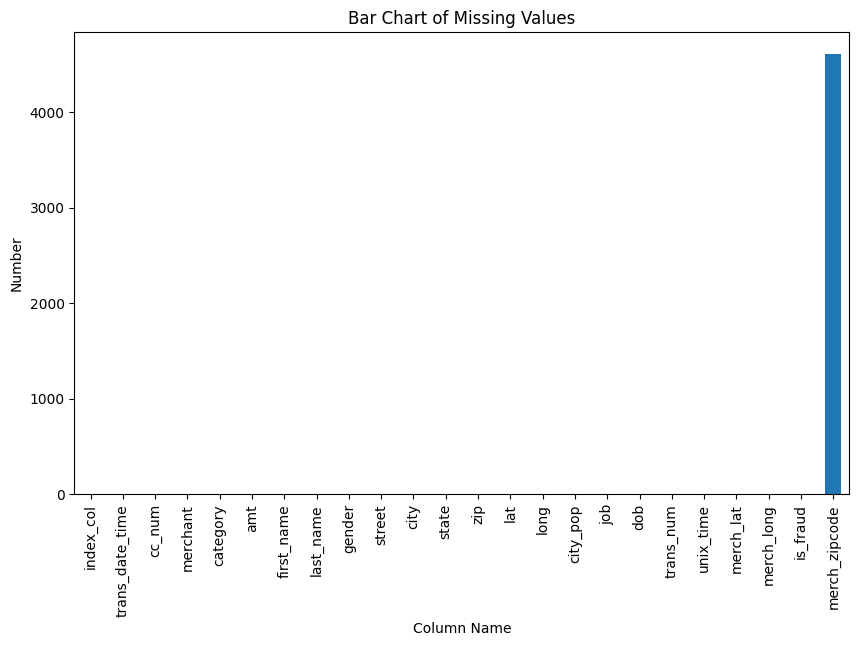

In [9]:
# Display the bar chart of missing values
plt.figure(figsize=(10,6))
df.isnull().sum().sort_values().plot(kind='bar')
plt.title('Bar Chart of Missing Values')
plt.xlabel('Column Name')
plt.ylabel('Number')
plt.show()

Missing values in the column '**merch_zipcode**' could be a fraud signal. A '**missing_merch_zip**' feature will be created.

In [10]:
# Confirm the column with missing values
column_missing_values = df.columns[df.isnull().any()].tolist()
column_missing_values

['merch_zipcode']

In [11]:
# Verify 'merchant' column distribution
val_count_merchant = df['merchant'].value_counts()

print(val_count_merchant)

merchant
fraud_Kilback LLC                        103
fraud_Schumm PLC                          92
fraud_Cormier LLC                         87
fraud_Wolf Inc                            80
fraud_Berge LLC                           77
                                        ... 
fraud_Hackett Group                       13
fraud_Jaskolski-Dibbert                   12
fraud_Reichel, Bradtke and Blanda         12
fraud_Hahn, Douglas and Schowalter        11
fraud_Hodkiewicz, Prohaska and Paucek     10
Name: count, Length: 693, dtype: int64


In [12]:
# Strip the 'fraud_' prefix
df['merchant'] = df['merchant'].str.replace('fraud_', '', case=False)

In [13]:
# Re-verify 'merchant' column distribution
val_count_merchant = df['merchant'].value_counts()

print(val_count_merchant.head())

merchant
Kilback LLC    103
Schumm PLC      92
Cormier LLC     87
Wolf Inc        80
Berge LLC       77
Name: count, dtype: int64


In [14]:
# Verify 'category' column distribution
val_count_category = df['category'].value_counts()

print(val_count_category)

category
gas_transport     3034
grocery_pos       2911
home              2798
shopping_pos      2665
kids_pets         2506
shopping_net      2288
food_dining       2151
entertainment     2144
personal_care     2065
health_fitness    2044
misc_pos          1898
misc_net          1471
grocery_net       1048
travel             977
Name: count, dtype: int64


In [15]:
# Verify 'gender' column distribution
val_count_gender = df['gender'].value_counts()

print(val_count_gender.head())

gender
F    16422
M    13578
Name: count, dtype: int64


In [16]:
# Verify 'city' column distribution
val_count_city = df['city'].value_counts()

print(val_count_city.head())

city
Birmingham     134
Utica          131
San Antonio    131
Conway         128
Phoenix        122
Name: count, dtype: int64


In [17]:
# Verify 'state' column distribution
val_count_state = df['state'].value_counts()

print(val_count_state.head())

state
TX    2241
NY    1895
PA    1874
CA    1264
MI    1070
Name: count, dtype: int64


In [18]:
# Verify 'zip' column distribution
val_count_zip = df['zip'].value_counts()

print(val_count_zip.head())

zip
34112.0    88
28405.0    86
72042.0    85
48088.0    85
4287.0     85
Name: count, dtype: int64


In [19]:
# Convert 'zip' to string and remove any decimals (like .0)
df['zip'] = df['zip'].astype(str).str.replace('\.0', '', regex=True)

# Pad with leading zeros so everything is exactly 5 digits
df['zip'] = df['zip'].str.zfill(5)

# Check for anything that isn't 5 digits after padding
invalid_zips = df[df['zip'].str.len() != 5]

print(f"Rows with invalid zips: {len(invalid_zips)}")

Rows with invalid zips: 0


In [20]:
# Re-verify 'zip' column distribution
val_count_zip = df['zip'].value_counts()

print(val_count_zip.head())

zip
34112    88
28405    86
72042    85
48088    85
04287    85
Name: count, dtype: int64


In [21]:
# Convert 'lat' and 'long' data type
df['lat'] = df['lat'].astype(float)
df['long'] = df['long'].astype(float)

In [22]:
# Convert 'city_pop' data type
df['city_pop'] = df['city_pop'].astype(int)

In [23]:
# Verify 'job' column distribution
val_count_job = df['job'].value_counts()

print(val_count_job.head())

job
Exhibition designer         227
Film/video editor           215
Surveyor, land/geomatics    199
Naval architect             194
Materials engineer          190
Name: count, dtype: int64


In [24]:
# Define function to compute the distance between the user and the merchant
def haversine_np(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    miles = 6367 * c * 0.621
    return miles

In [25]:
# Define function to transform and create predictive features
def create_features(df):
    df = df.copy()

    # regional zip
    df['zip_region'] = df['zip'].str[0]

    # time since last purchase
    df = df.sort_values(by=['cc_num', 'unix_time'])
    df['time_delta'] = df.groupby('cc_num')['unix_time'].diff() / 60
    df['time_delta'] = df['time_delta'].fillna(-1) # -1 indicates first purchase

    # amount deviation
    user_avg_amt = df.groupby('cc_num')['amt'].transform('mean')
    df['amt_vs_avg'] = df['amt'] / user_avg_amt

    # distance to merchant
    df['dist_to_merch'] = haversine_np(df['long'], df['lat'], df['merch_long'], df['merch_lat'])

    # transaction velocity in  miles per hour
    df['travel_speed'] = df['dist_to_merch'] / (df['time_delta'] / 60)
    df['travel_speed'] = df['travel_speed'].replace([np.inf, -np.inf], 0).fillna(0)

    # datetime
    df["trans_date_time"] = pd.to_datetime(df["trans_date_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    # hour of day
    df["hour"] = df["trans_date_time"].dt.hour
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    # day of week
    df["day_num"] = df["trans_date_time"].dt.dayofweek
    df["dow_sin"] = np.sin(2*np.pi*df["day_num"]/7)
    df["dow_cos"] = np.cos(2*np.pi*df["day_num"]/7)

    # flags
    df["is_night"] = df["hour"].between(0,5).astype(int)
    df["is_weekend"] = (df["day_num"] >= 5).astype(int)

    # age
    df["age"] = df["trans_date_time"].dt.year - df["dob"].dt.year

    # amount
    df["amt_log"] = np.log1p(df["amt"])
    df["high_amt"] = (df["amt"] > df["amt"].quantile(0.95)).astype(int)

    # merchant frequency
    df["merchant_freq"] = df.groupby("merchant")["merchant"].transform("count")

    # missing merchant zip
    df["missing_merch_zip"] = df["merch_zipcode"].isna().astype(int)

    return df

In [26]:
# Apply the function
df = create_features(df)

In [27]:
# Top 10 fastest 'fraud' transactions
top_fraud_speeds = df[df['is_fraud'] == 1].sort_values(by='travel_speed', ascending=False)

# Display the speed, the time gap, and the distance
print(top_fraud_speeds[['travel_speed', 'time_delta', 'dist_to_merch']].head(10))

       travel_speed  time_delta  dist_to_merch
19737   1579.234948    2.433333      64.046751
12364    921.051333    4.333333      66.520374
28276    651.700199    6.166667      66.980298
490      539.516473    5.716667      51.403931
20295    538.744019    8.433333      75.723465
6244     531.053396    5.366667      47.499776
7769     529.145368    4.066667      35.864297
12753    505.317187    6.550000      55.163793
5908     362.015105    7.266667      43.844052
18511    305.550145   15.533333      79.103538


The plot of **Distance vs Time** gap between transactions displays the fraud transactions where the time is short and the distance is long.

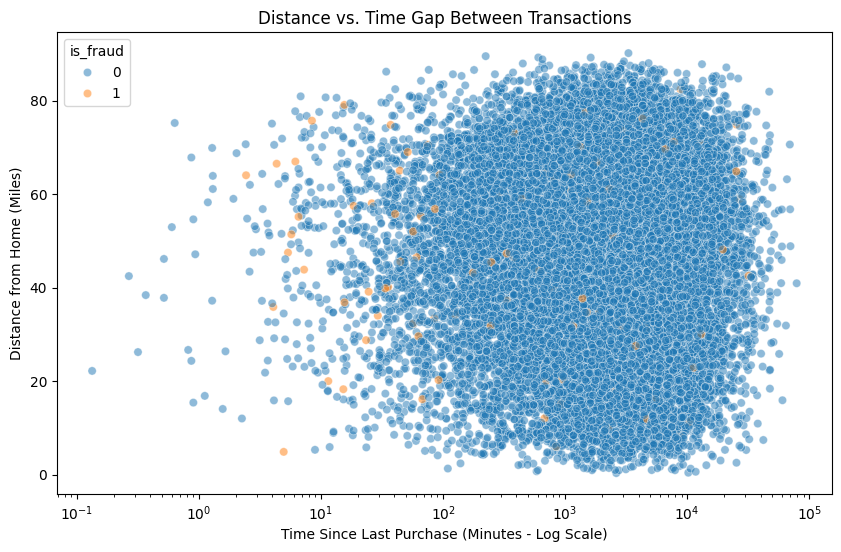

In [28]:
plt.figure(figsize=(10,6))
# Plotting distance vs time gap, colored by fraud
sns.scatterplot(data=df, x='time_delta', y='dist_to_merch', hue='is_fraud', alpha=0.5)

plt.xscale('log') # Use log scale because time gaps can be huge
plt.title('Distance vs. Time Gap Between Transactions')
plt.xlabel('Time Since Last Purchase (Minutes - Log Scale)')
plt.ylabel('Distance from Home (Miles)')
plt.show()

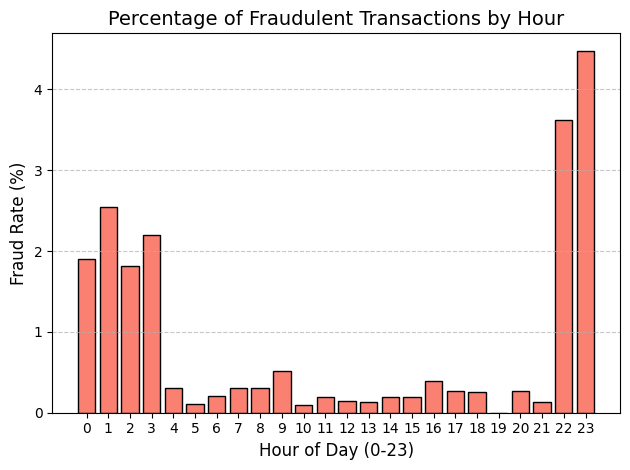

In [29]:
# Calculate the percentage of fraud for each hour
# Since 'is_fraud' is 0 or 1, the mean() gives the percentage
hour_fraud_rate = df.groupby('hour')['is_fraud'].mean() * 100

# Create the Bar Chart
plt.bar(hour_fraud_rate.index, hour_fraud_rate.values, color='salmon', edgecolor='black')

# Add labels and formatting
plt.title('Percentage of Fraudulent Transactions by Hour', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Fraud Rate (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# Drop low value features
drop_cols = [
    "index_col",
    "first_name",
    "last_name",
    "street",
    "trans_num",
    "trans_date_time",
    "dob",
    "hour",
    "day_num",
    "amt",
    "merch_zipcode",
    "zip",
    "cc_num",
    "unix_time",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "merchant"
]

df = df.drop(columns=drop_cols)

In [31]:
# Examine data
df.head().T

,3870,10770,96,29934,28918
category,gas_transport,personal_care,entertainment,food_dining,gas_transport
gender,F,F,F,F,F
city,Fort Washakie,Fort Washakie,Fort Washakie,Fort Washakie,Fort Washakie
state,WY,WY,WY,WY,WY
city_pop,1645,1645,1645,1645,1645
job,Information systems manager,Information systems manager,Information systems manager,Information systems manager,Information systems manager
is_fraud,0,0,0,0,0
zip_region,8,8,8,8,8
time_delta,-1.0,3629.766667,5887.35,4354.783333,526.95
amt_vs_avg,1.646617,0.536435,1.634581,0.139625,0.988011


In [32]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 3870 to 3932
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           30000 non-null  object 
 1   gender             30000 non-null  object 
 2   city               30000 non-null  object 
 3   state              30000 non-null  object 
 4   city_pop           30000 non-null  int64  
 5   job                30000 non-null  object 
 6   is_fraud           30000 non-null  int64  
 7   zip_region         30000 non-null  object 
 8   time_delta         30000 non-null  float64
 9   amt_vs_avg         30000 non-null  float64
 10  dist_to_merch      30000 non-null  float64
 11  travel_speed       30000 non-null  float64
 12  hour_sin           30000 non-null  float64
 13  hour_cos           30000 non-null  float64
 14  dow_sin            30000 non-null  float64
 15  dow_cos            30000 non-null  float64
 16  is_night           30000 

**Box Plots**     
Overlapping negative and positive boxes are not good predictors particularly when the medians are almost the same.    
Separation of the boxes like in '**hour_cos**', '**high_amt**', '**amt_log**', '**is_night**', and '**is_weekend**' are good predictors.     

The **outliers** outside the whiskers will be allowed to stay to preserve the fraud signals in these outliers.

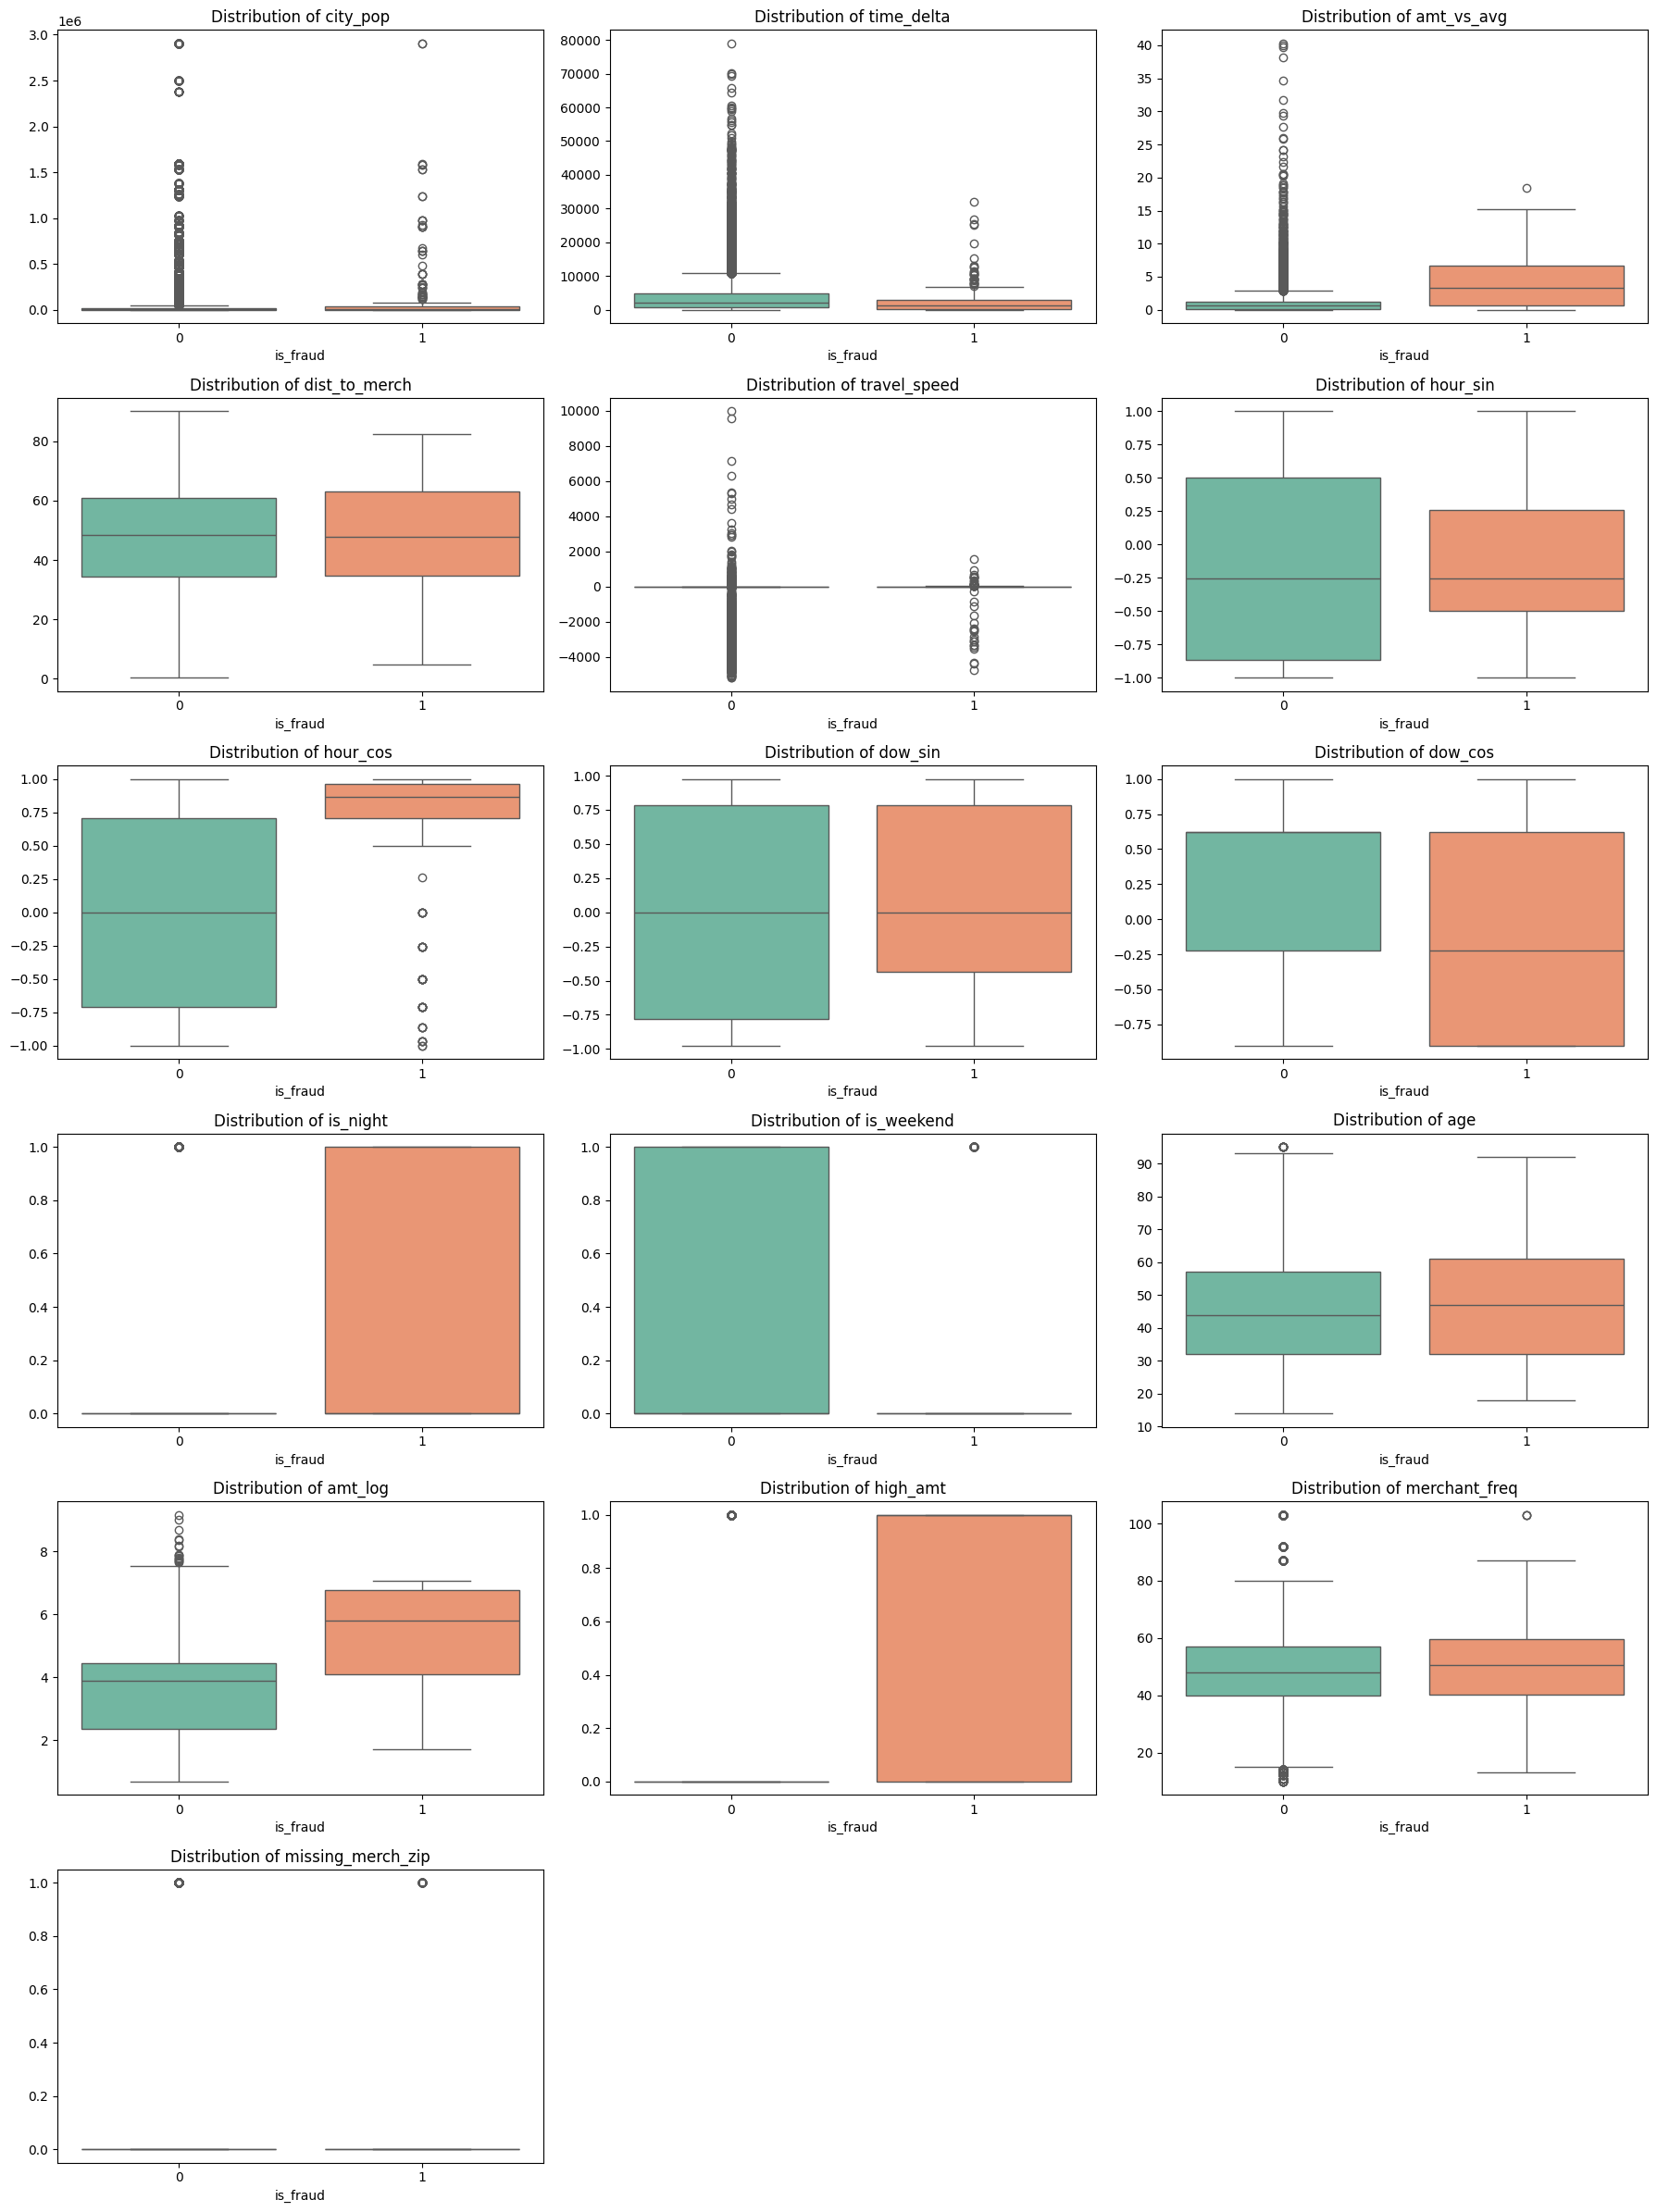

In [33]:
# Display box plots of numerical features in subplots of 3 columns before removal of outliers
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numerical_columns if col != 'is_fraud']

n_features = len(numeric_cols)
n_cols = 3
n_rows = math.ceil(n_features/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df['is_fraud'], y=df[col], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Good predictors have divergent **medians** with respect to the negative and positive classes like '**hour_cos**', '**amt_log**', '**time_delta**', '**amt_vs_avg**', '**dow_cos**', and '**travel_speed**'.

In [34]:
# Display features medians of negative and positive classes
medians = df.groupby('is_fraud')[numeric_cols].median().T
medians

is_fraud,0,1
city_pop,2.435000e+03,2691.000000
time_delta,2.134467e+03,1285.716667
amt_vs_avg,6.622538e-01,3.261546
dist_to_merch,4.855845e+01,47.907739
travel_speed,1.118786e+00,1.635475
hour_sin,-2.588190e-01,-0.258819
hour_cos,-1.836970e-16,0.866025
dow_sin,0.000000e+00,0.000000
dow_cos,6.234898e-01,-0.222521
is_night,0.000000e+00,0.000000


**Histograms of Classes**

The difference in the mean and median of the legitimate and fraudulent cases lend to the strength of the predictive property of the features.


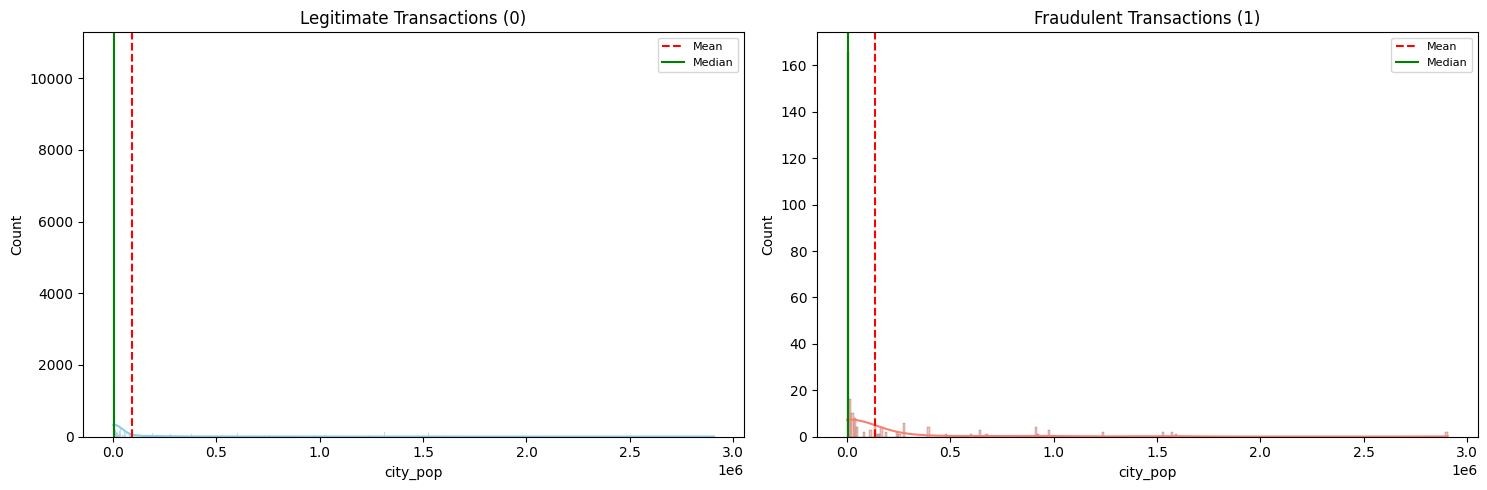

In [35]:
# Histogram of 'city_pop'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['city_pop'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['city_pop'].mean()
col_median = df[df['is_fraud']==0]['city_pop'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['city_pop'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['city_pop'].mean()
col_median = df[df['is_fraud']==1]['city_pop'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

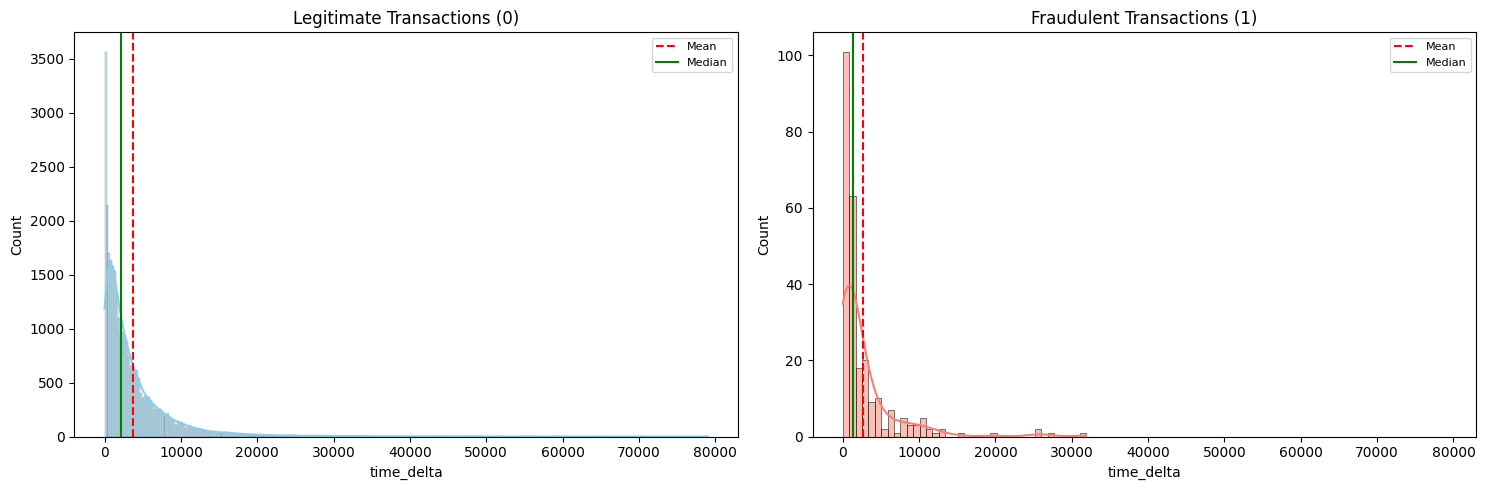

In [36]:
# Histogram of 'time_delta'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['time_delta'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['time_delta'].mean()
col_median = df[df['is_fraud']==0]['time_delta'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['time_delta'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['time_delta'].mean()
col_median = df[df['is_fraud']==1]['time_delta'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

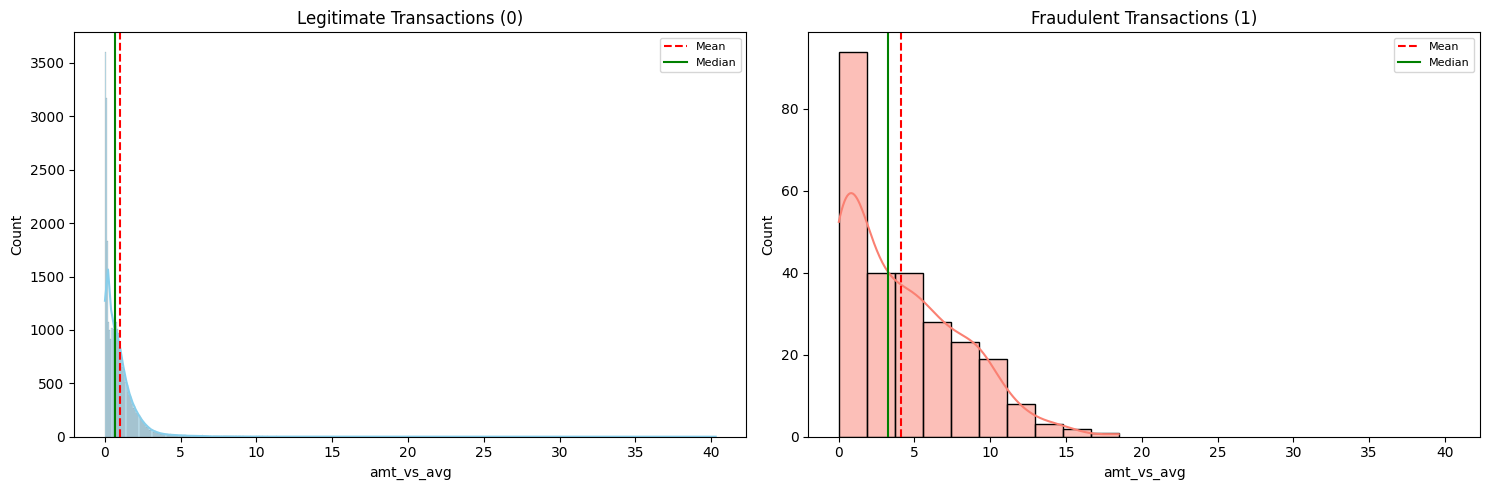

In [37]:
# Histogram of 'amt_vs_avg'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['amt_vs_avg'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['amt_vs_avg'].mean()
col_median = df[df['is_fraud']==0]['amt_vs_avg'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['amt_vs_avg'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['amt_vs_avg'].mean()
col_median = df[df['is_fraud']==1]['amt_vs_avg'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

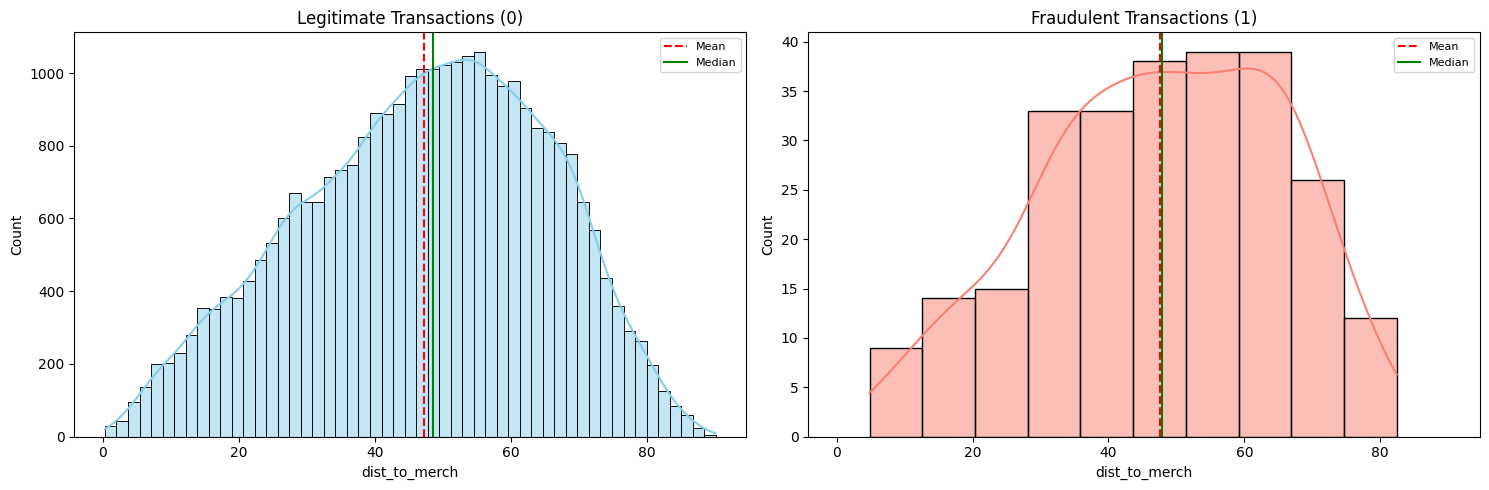

In [38]:
# Histogram of 'dist_to_merch'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['dist_to_merch'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['dist_to_merch'].mean()
col_median = df[df['is_fraud']==0]['dist_to_merch'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['dist_to_merch'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['dist_to_merch'].mean()
col_median = df[df['is_fraud']==1]['dist_to_merch'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

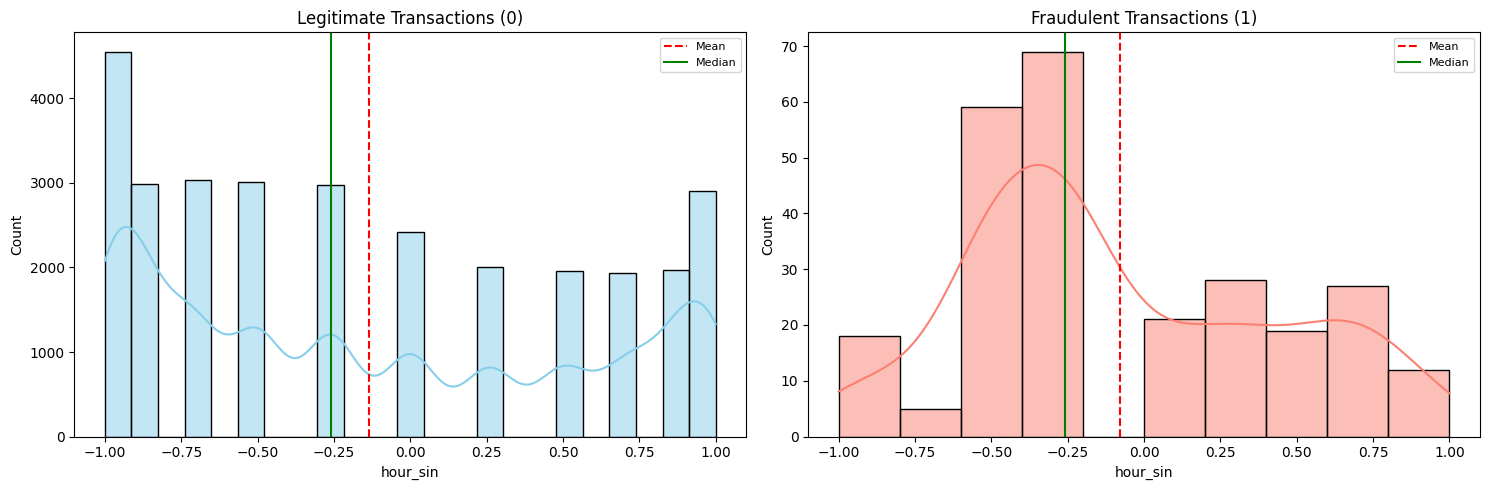

In [39]:
# Histogram of 'hour_sin'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['hour_sin'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['hour_sin'].mean()
col_median = df[df['is_fraud']==0]['hour_sin'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['hour_sin'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['hour_sin'].mean()
col_median = df[df['is_fraud']==1]['hour_sin'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

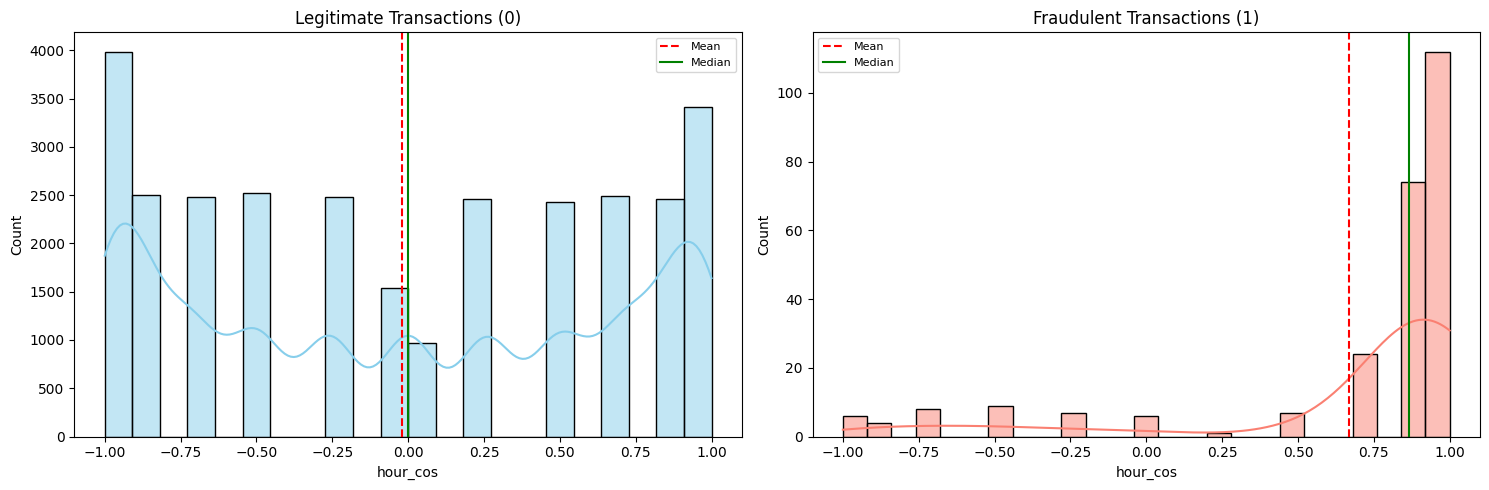

In [40]:
# Histogram of 'hour_cos'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['hour_cos'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['hour_cos'].mean()
col_median = df[df['is_fraud']==0]['hour_cos'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['hour_cos'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['hour_cos'].mean()
col_median = df[df['is_fraud']==1]['hour_cos'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

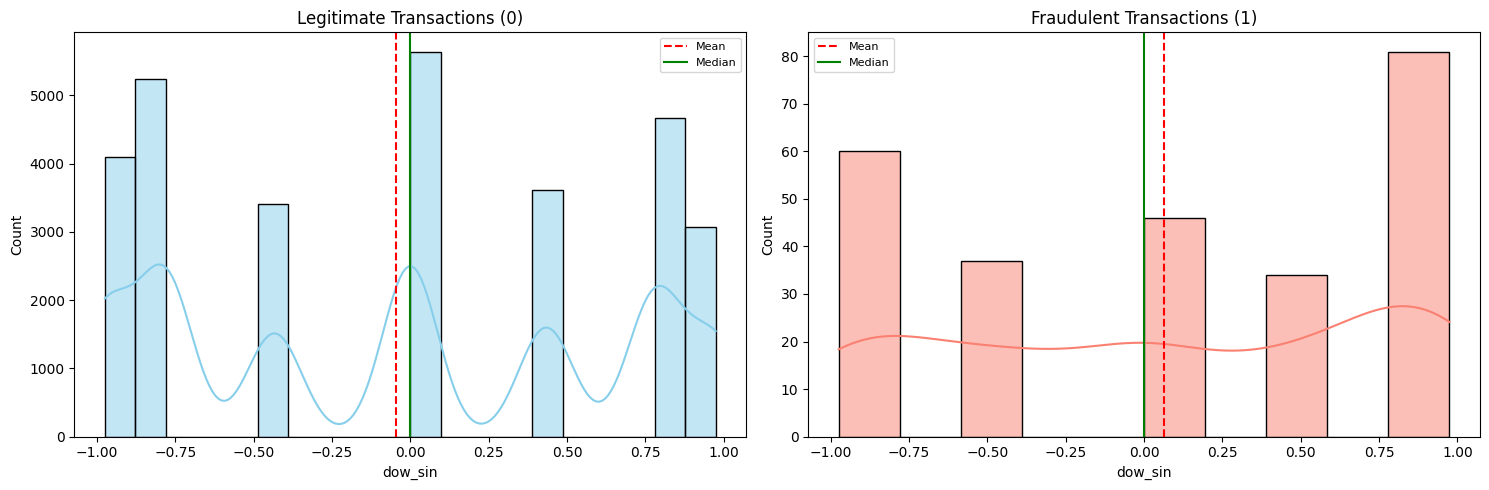

In [41]:
# Histogram of 'dow_sin'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['dow_sin'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['dow_sin'].mean()
col_median = df[df['is_fraud']==0]['dow_sin'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['dow_sin'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['dow_sin'].mean()
col_median = df[df['is_fraud']==1]['dow_sin'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

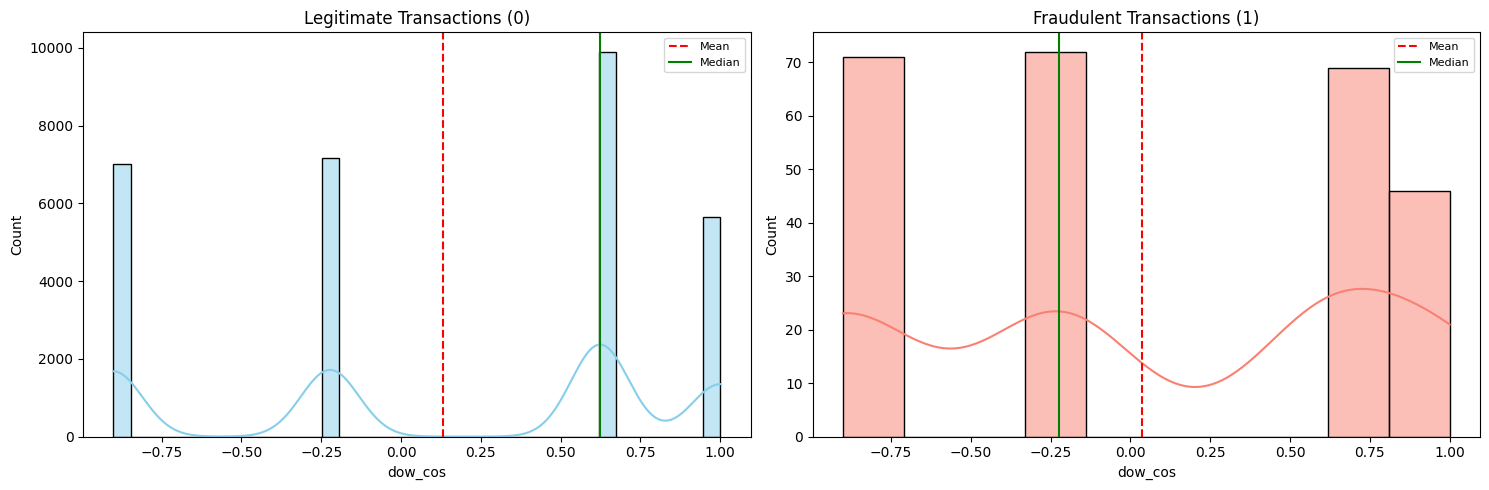

In [42]:
# Histogram of 'dow_cos'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['dow_cos'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['dow_cos'].mean()
col_median = df[df['is_fraud']==0]['dow_cos'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['dow_cos'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['dow_cos'].mean()
col_median = df[df['is_fraud']==1]['dow_cos'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

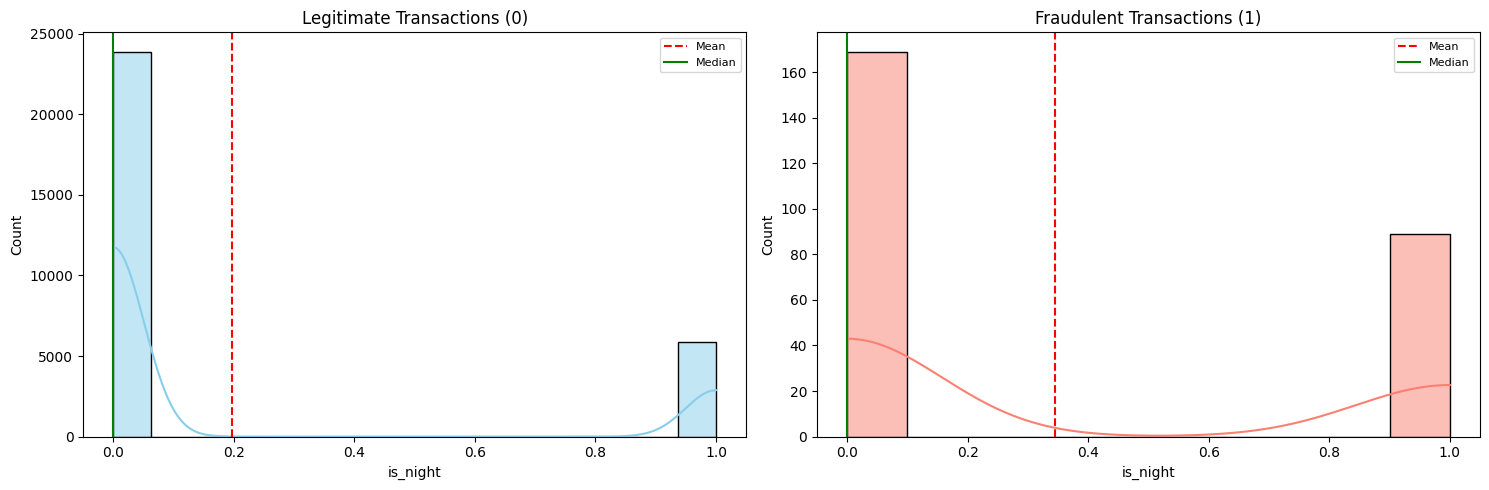

In [43]:
# Histogram of 'is_night'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['is_night'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['is_night'].mean()
col_median = df[df['is_fraud']==0]['is_night'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['is_night'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['is_night'].mean()
col_median = df[df['is_fraud']==1]['is_night'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

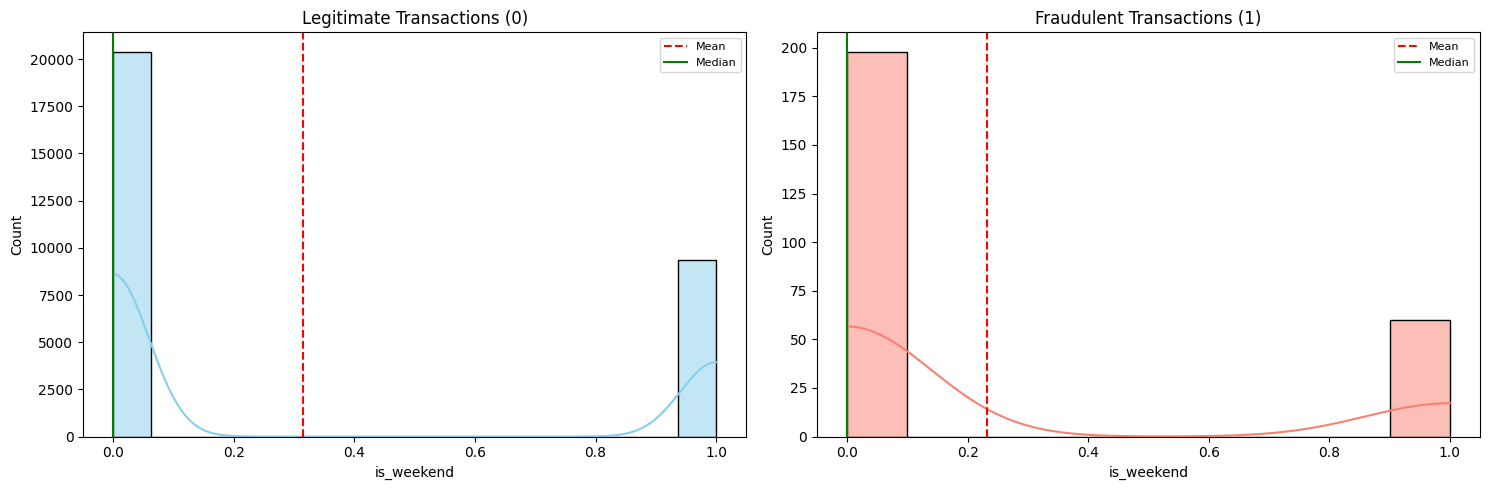

In [44]:
# Histogram of 'is_weekend'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['is_weekend'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['is_weekend'].mean()
col_median = df[df['is_fraud']==0]['is_weekend'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['is_weekend'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['is_weekend'].mean()
col_median = df[df['is_fraud']==1]['is_weekend'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

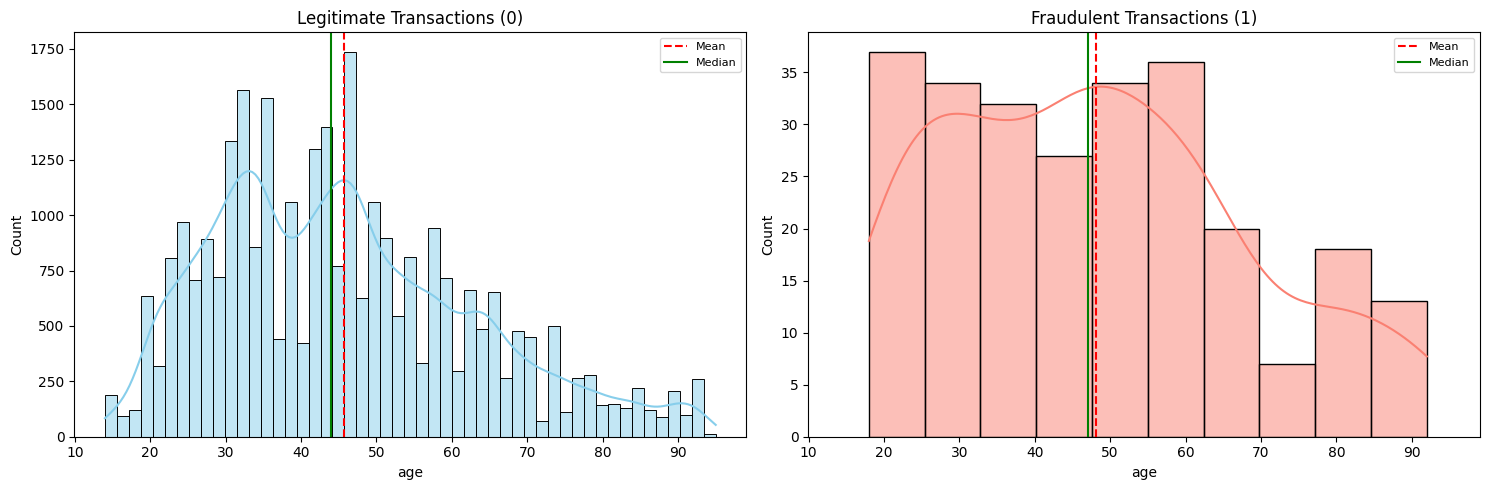

In [45]:
# Histogram of 'age'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['age'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['age'].mean()
col_median = df[df['is_fraud']==0]['age'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['age'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['age'].mean()
col_median = df[df['is_fraud']==1]['age'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

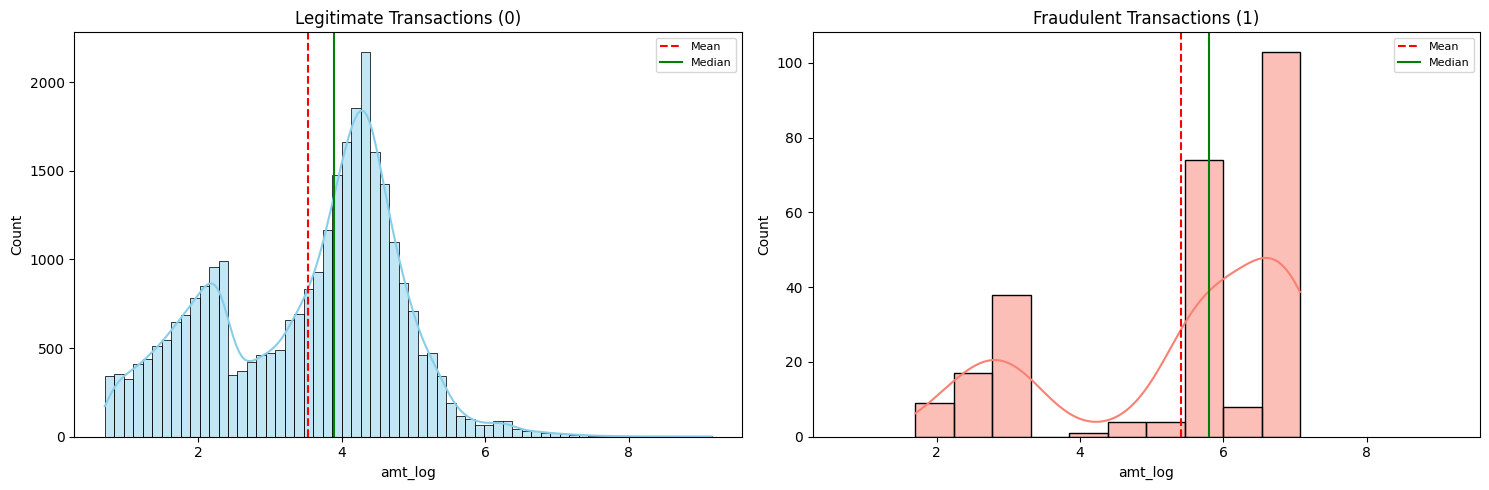

In [46]:
# Histogram of 'amt_log'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['amt_log'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['amt_log'].mean()
col_median = df[df['is_fraud']==0]['amt_log'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['amt_log'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['amt_log'].mean()
col_median = df[df['is_fraud']==1]['amt_log'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

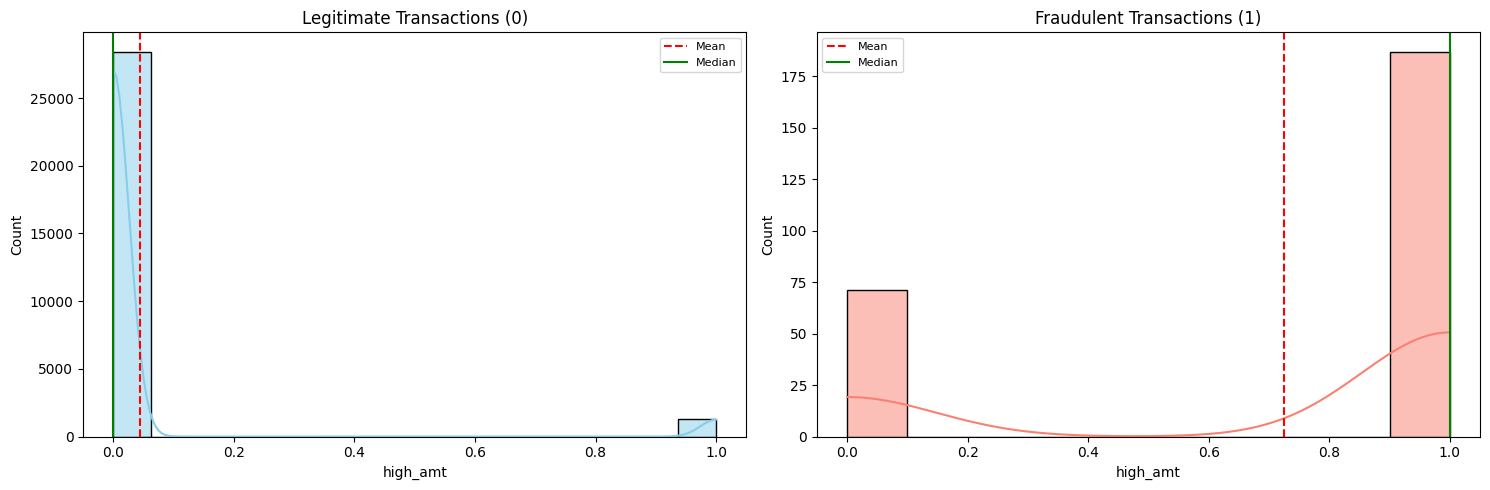

In [47]:
# Histogram of 'high_amt'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['high_amt'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['high_amt'].mean()
col_median = df[df['is_fraud']==0]['high_amt'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['high_amt'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['high_amt'].mean()
col_median = df[df['is_fraud']==1]['high_amt'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

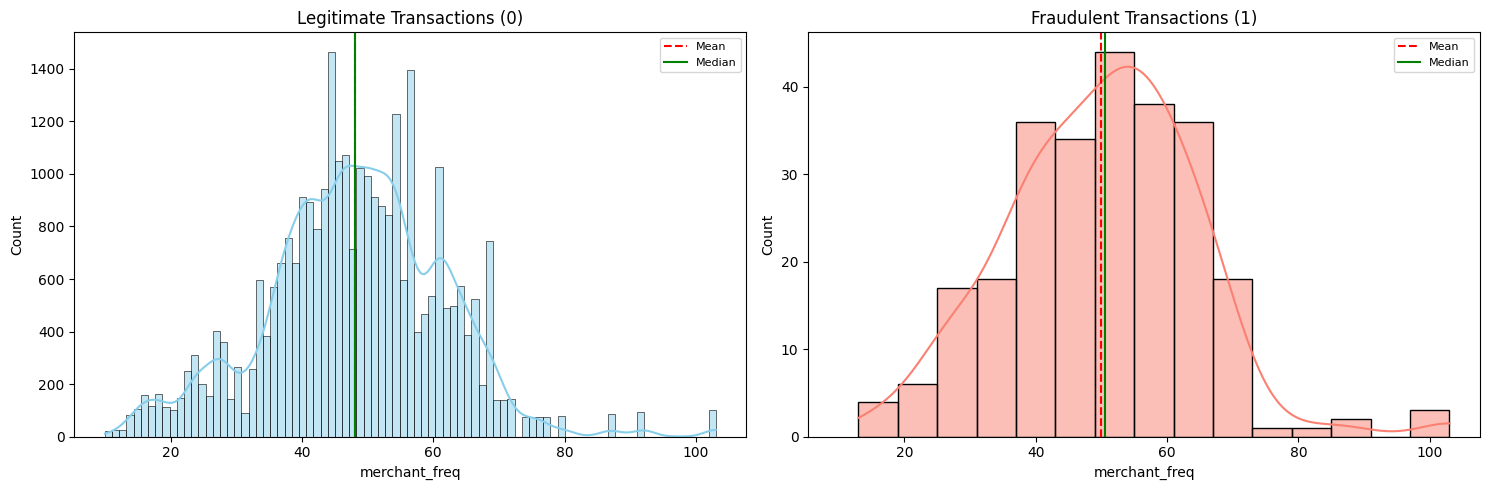

In [48]:
# Histogram of 'merchant_freq'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['merchant_freq'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['merchant_freq'].mean()
col_median = df[df['is_fraud']==0]['merchant_freq'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['merchant_freq'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['merchant_freq'].mean()
col_median = df[df['is_fraud']==1]['merchant_freq'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

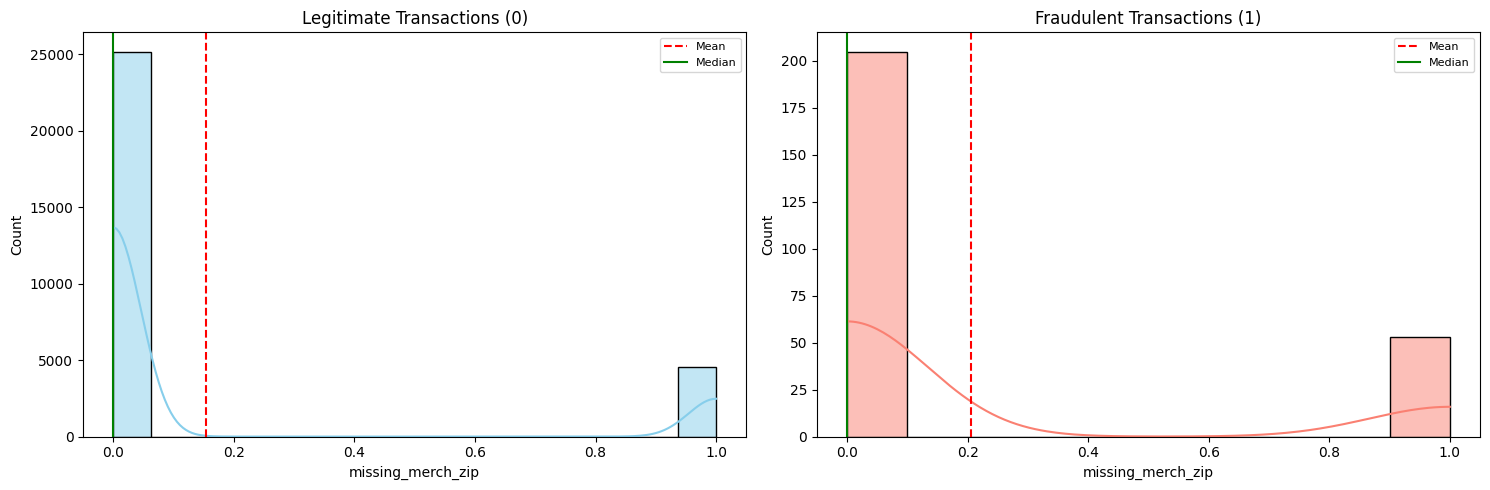

In [49]:
# Histogram of 'missing_merch_zip'
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Legitimate
sns.histplot(df[df['is_fraud']==0]['missing_merch_zip'], kde=True, ax=axes[0], color='skyblue')
col_mean = df[df['is_fraud']==0]['missing_merch_zip'].mean()
col_median = df[df['is_fraud']==0]['missing_merch_zip'].median()
axes[0].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[0].axvline(col_median, color='green', linestyle='-', label='Median')
axes[0].set_title('Legitimate Transactions (0)')
axes[0].legend(fontsize=8)

# Plot Fraud
sns.histplot(df[df['is_fraud']==1]['missing_merch_zip'], kde=True, ax=axes[1], color='salmon')
col_mean = df[df['is_fraud']==1]['missing_merch_zip'].mean()
col_median = df[df['is_fraud']==1]['missing_merch_zip'].median()
axes[1].axvline(col_mean, color='red', linestyle='--', label='Mean')
axes[1].axvline(col_median, color='green', linestyle='-', label='Median')
axes[1].set_title('Fraudulent Transactions (1)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Stacked Bars Plot**     

Fraud is more likely in the following category: **grocery_pos**, **shopping_net**, **misc_net**, and **shopping_pos**.     

The distribution of fraud **gender**-wise is similar.

There is more likelihood of fraud in **zip_region** numbers 9, 6, and 4.


In [50]:
# Define a function to plot stacked bars with annotated percentages of fraud status
def plot_stacked_bars(df, features, target='is_fraud', n_cols=1):
    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*8))
    axes_flat = axes.flatten()

    for i, col in enumerate(features):
        ax = axes_flat[i]
        cross_tab = pd.crosstab(df[col], df[target], normalize='index')
        cross_tab.plot(kind='barh', stacked=True, ax=ax, color=['#7294ac','#81c79d'], legend=False)
        for p in ax.patches:
            width = p.get_width()
            if width > 0.05:
                x_pos = p.get_x() + width / 2
                y_pos = p.get_y() + p.get_height() / 2
                ax.text(x_pos, y_pos, f'{width*100:.3f}%',
                        va='center', ha='center',
                        color='white', fontweight='bold', fontsize=11)
        ax.set_title(f'Fraud Distribution: {col}', fontsize=14)
        ax.set_xlabel('Proportion')
        ax.set_ylabel('')

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
                ncol=2, title=f'{target.capitalize()} Status', fontsize=12)

    for j in range(i+1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [51]:
# Fraud distribution
fraud_distribution = df['is_fraud'].value_counts(normalize=True)

print(fraud_distribution)

is_fraud
0    0.9914
1    0.0086
Name: proportion, dtype: float64


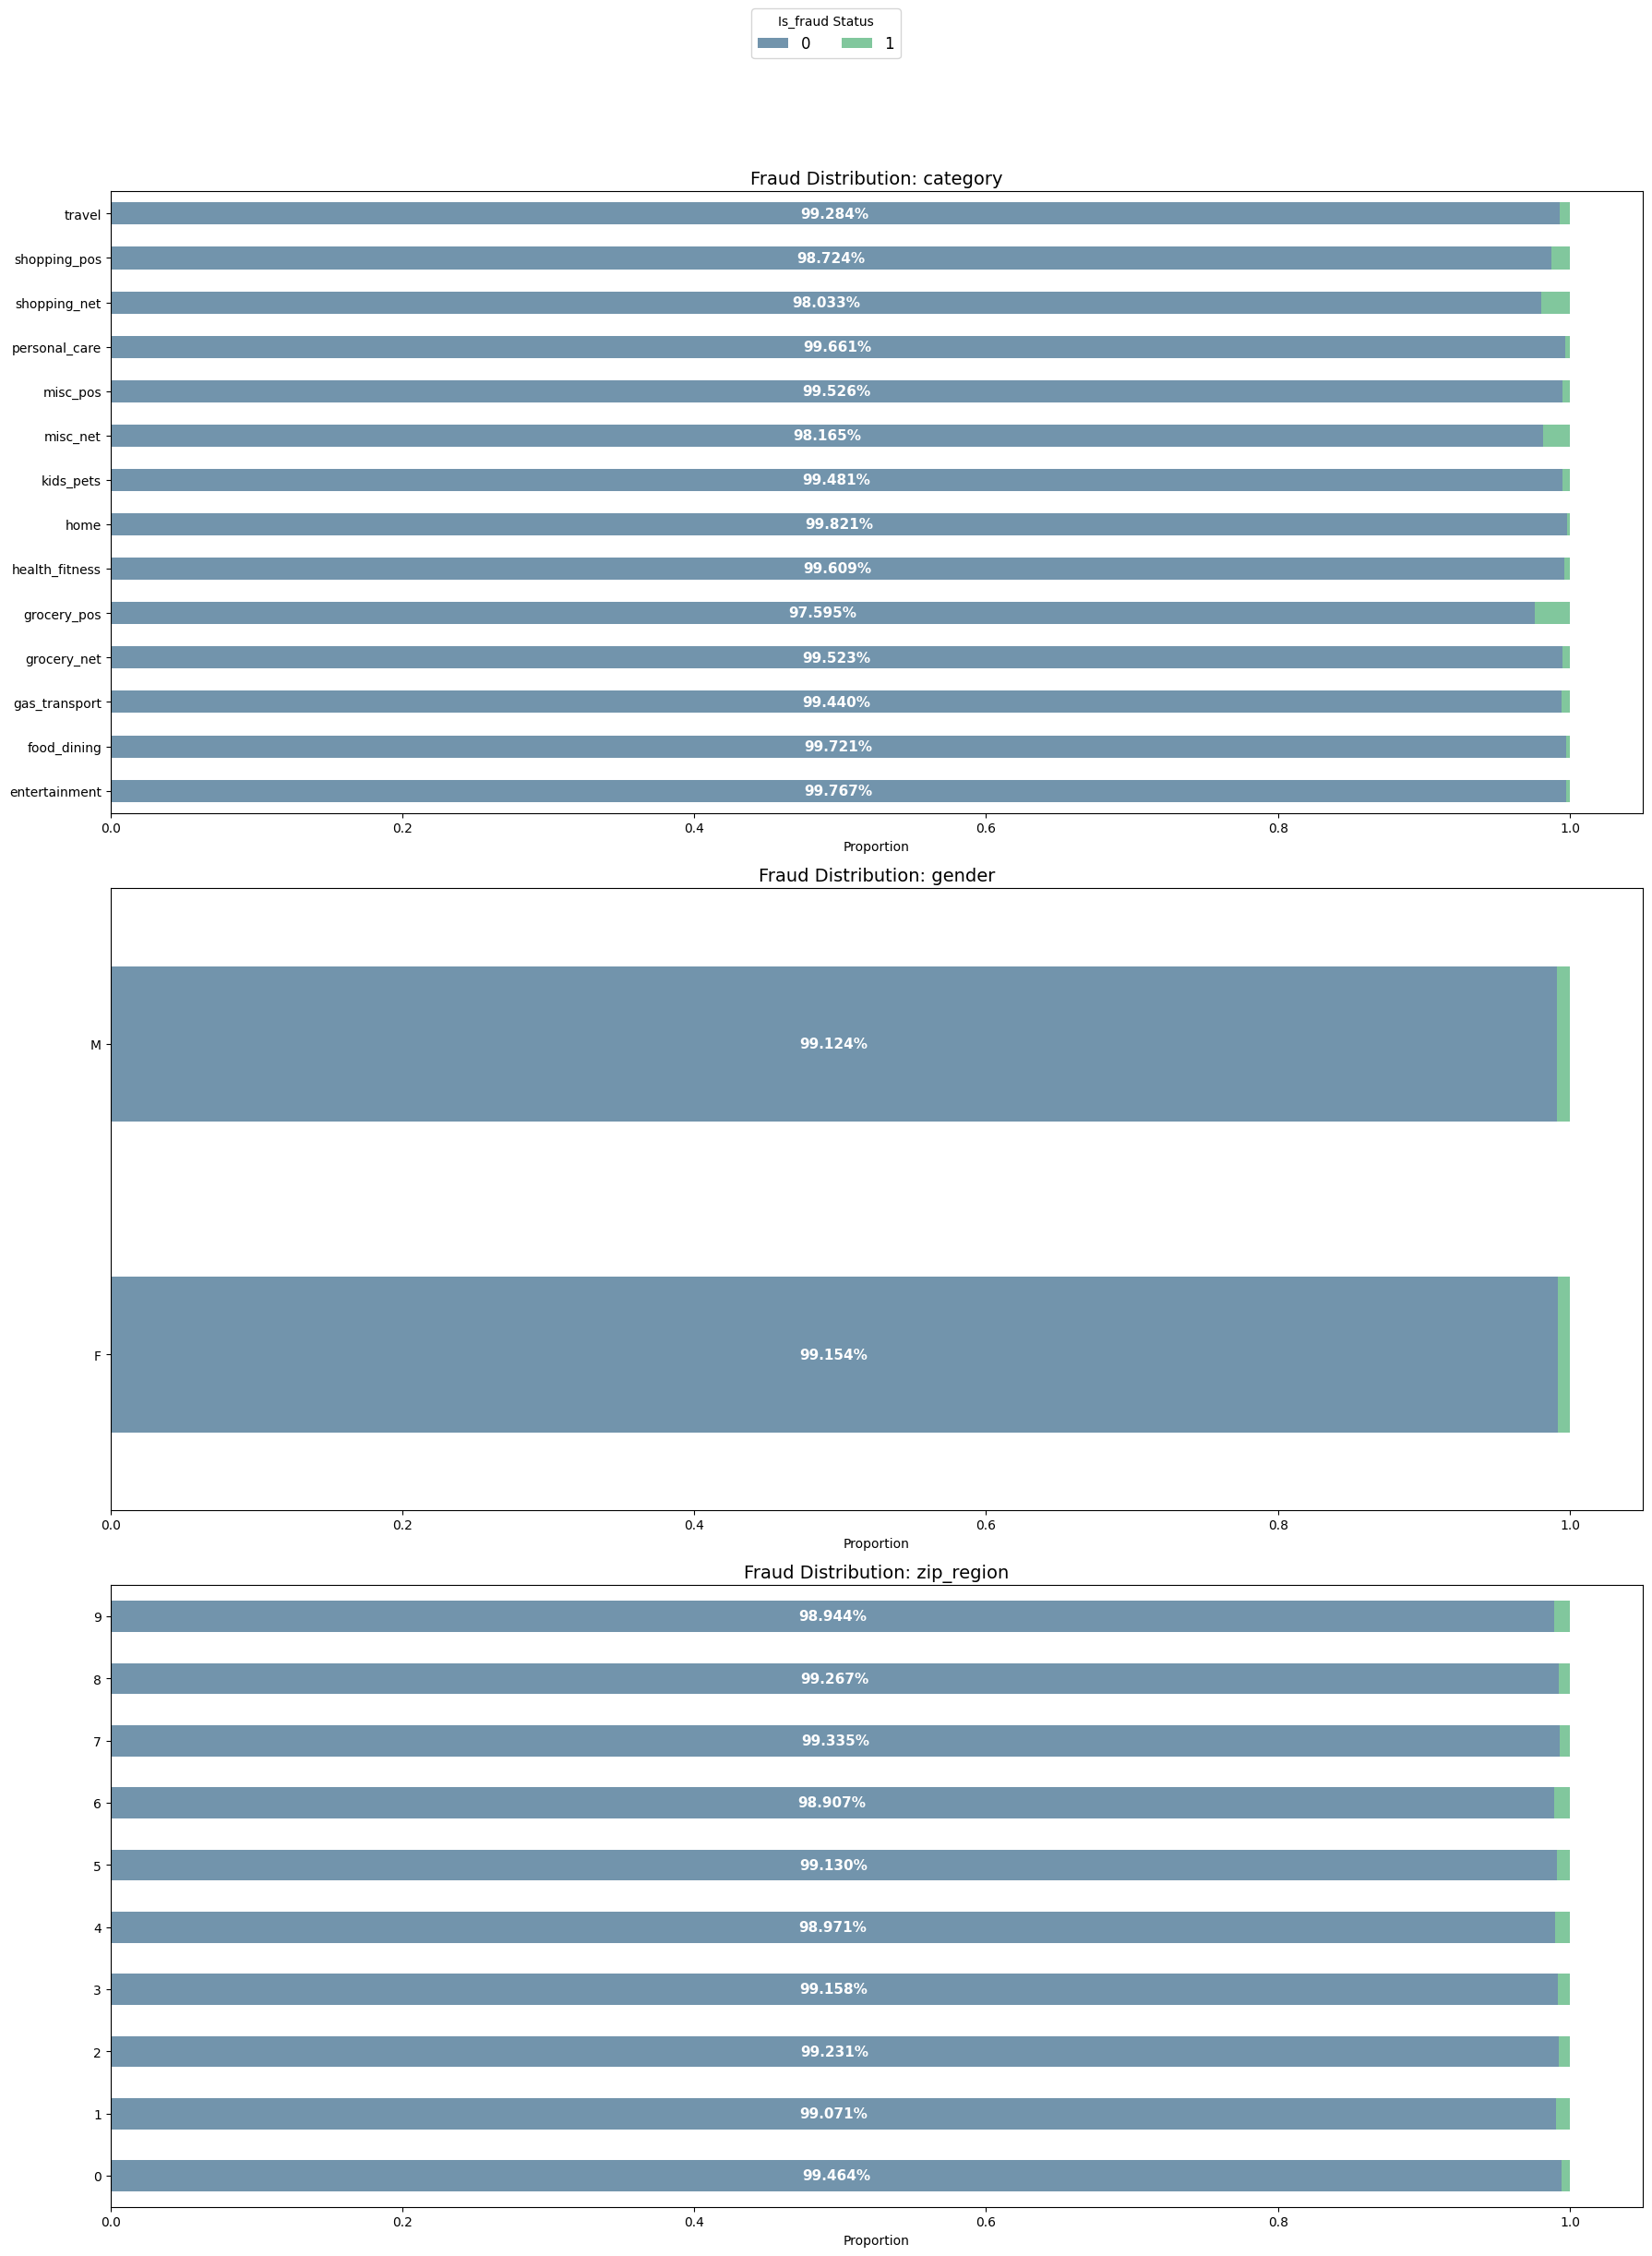

In [52]:
# Run the plot function on 3 categorical columns
categorical_columns = ['category', 'gender','zip_region']

plot_stacked_bars(df, categorical_columns)

**Heat Maps**

Fraud is highly correlated with the following features: '**amt_vs_avg**' (+0.20), '**amt_log**' (+0.13), '**high_amt**' (+0.29)     

High correlation is observed between '**is_weekend**' and '**dow_sin**' (-0.81). '**is_weekend**' is dropped depending on the model being built.

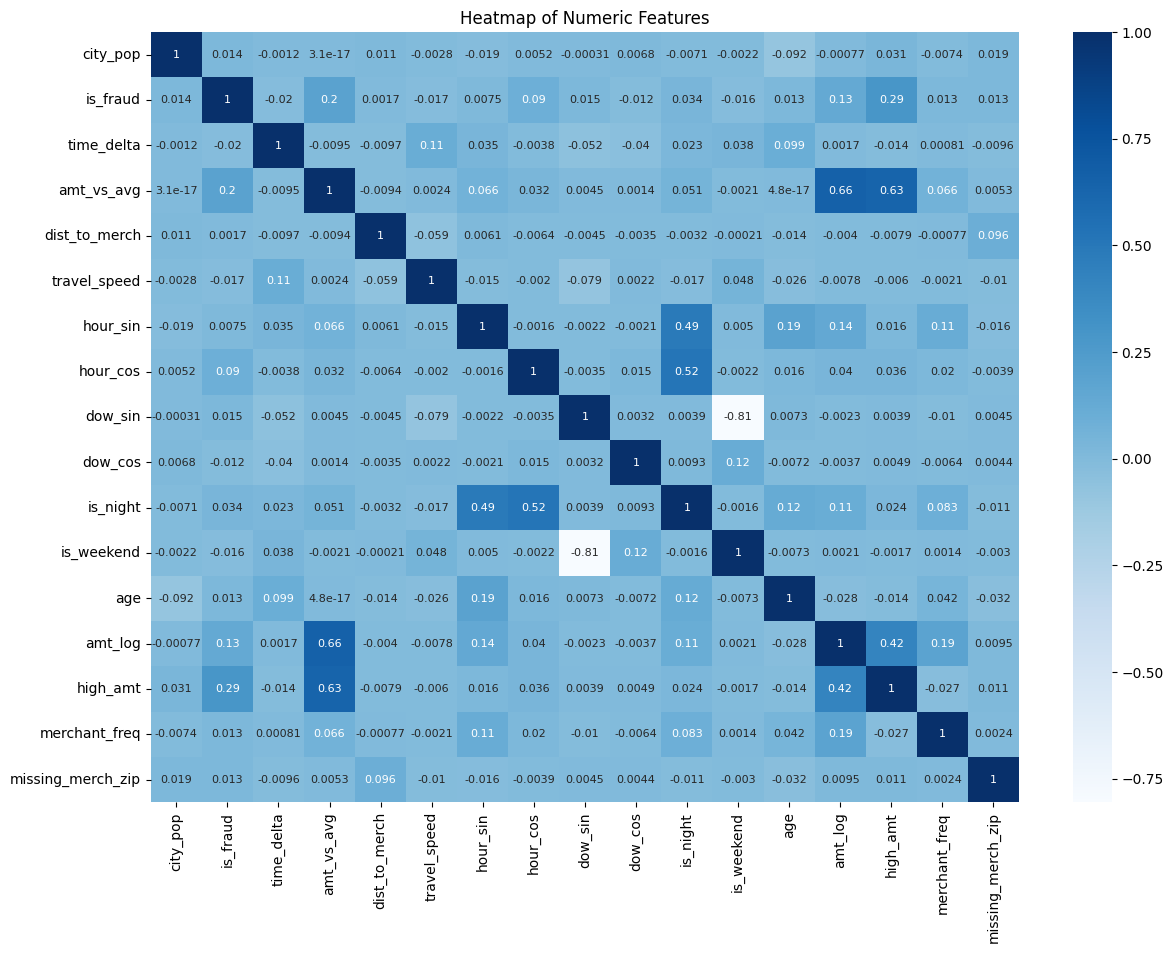

In [53]:
# Display the heat map of numeric features
df_numeric = df[numerical_columns]
plt.figure(figsize=(14,10))
ax = sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='Blues',
    annot_kws={"size": 8});
plt.title(f'Heatmap of Numeric Features')
plt.show()

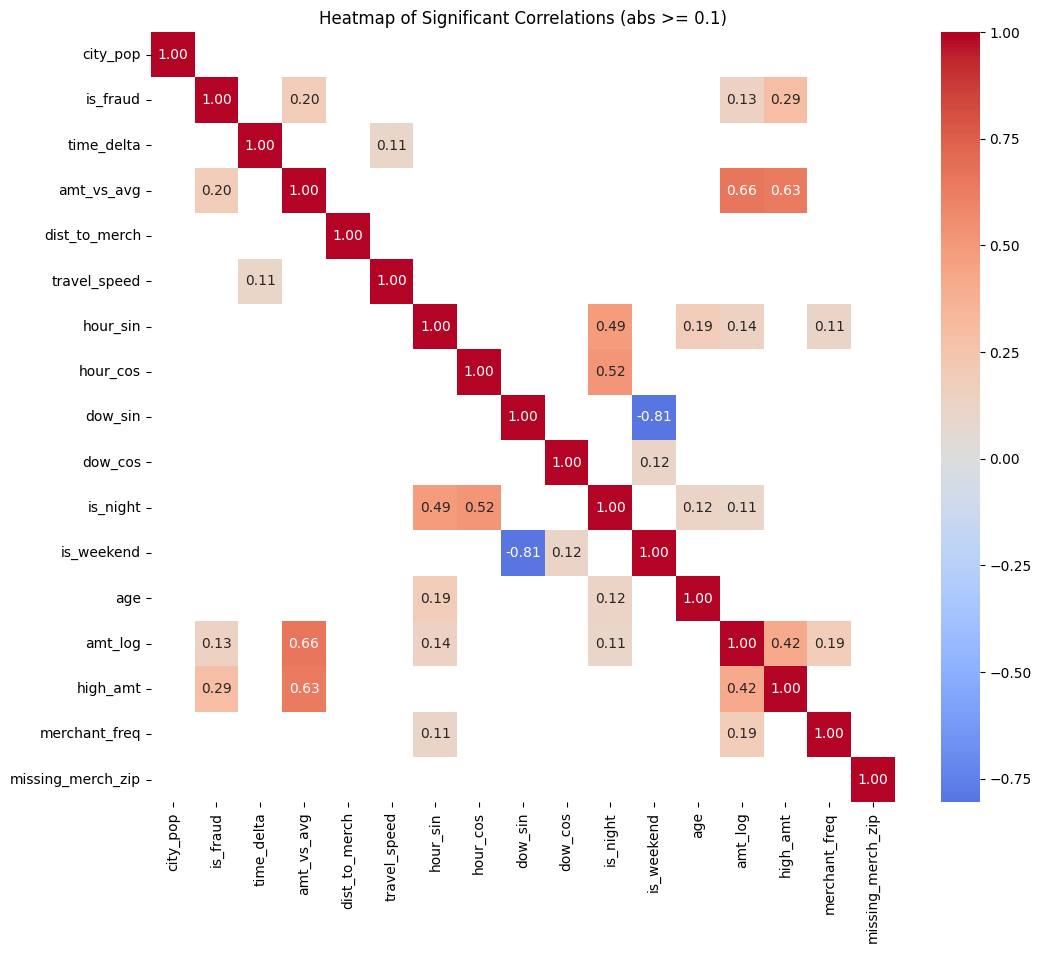

In [54]:
# Display heat map highlighting correlations >= threshold
corr_matrix = df_numeric.corr()
threshold = 0.1
sig_corr = corr_matrix[(corr_matrix.abs() >= threshold)]
plt.figure(figsize=(12,10))
sns.heatmap(sig_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title(f'Heatmap of Significant Correlations (abs >= {threshold})')
plt.show()

In [55]:
# Select the top 7 features for the pair plot analysis including 'is_fraud'
corr = df.corr(numeric_only=True)['is_fraud'].abs().sort_values(ascending=False)
top_features = corr.head(7).index.tolist()
top_features

['is_fraud',
 'high_amt',
 'amt_vs_avg',
 'amt_log',
 'hour_cos',
 'is_night',
 'time_delta']

**Pair Plot**   
     
**high_amt** - **diagonal** - there are more frauds are in high amounts. vs **amt_vs_avg** - most frauds are in high amounts and at low amt_vs_avg. vs **amt_log** - frauds not well indicated here. vs **hour_cos** - frauds not well indicated here. vs **is_night** - frauds not well indicated here. vs **time_delta** - frauds are in the high amount and at around 7-hour time delta.

**amt_vs_avg** - **diagonal** - most frauds happen beyond the average amount. vs **amt_log** - frauds happen at low amt_vs_avg and at around \$1,000. vs **hour_cos** - most frauds occur before midnight at around 12 times the average transaction. vs **is_night** - frauds happen day and night but at higher amt_vs_avg at night. vs **time_delta** - in less than 7 hours, frauds happen at around 10 times the average transaction

**amt_log** - **diagonal** - frauds happen at higher amounts. vs **hour_cos** - frauds happen around midnight and at dawn at around \$1,000 transactions.  vs **is_night** - frauds not well indicated here. vs **time_delta** - frauds happen in less than 7 hours at \$1,000 transactions     

**hour_cos** - **diagonal** - fraudulent transactions happen towards midnight. vs **is_night** - this feature is not a good predictor. vs **time_delta** - some indication of fraud after around 5 hours

**is_night** - **diagonal** - fraud distribution similar to legitimate transactions. vs **time_delta** - fraud not well indicated

**time_delta** - **diagonal** - fraud distribution similar to legitimate transactions

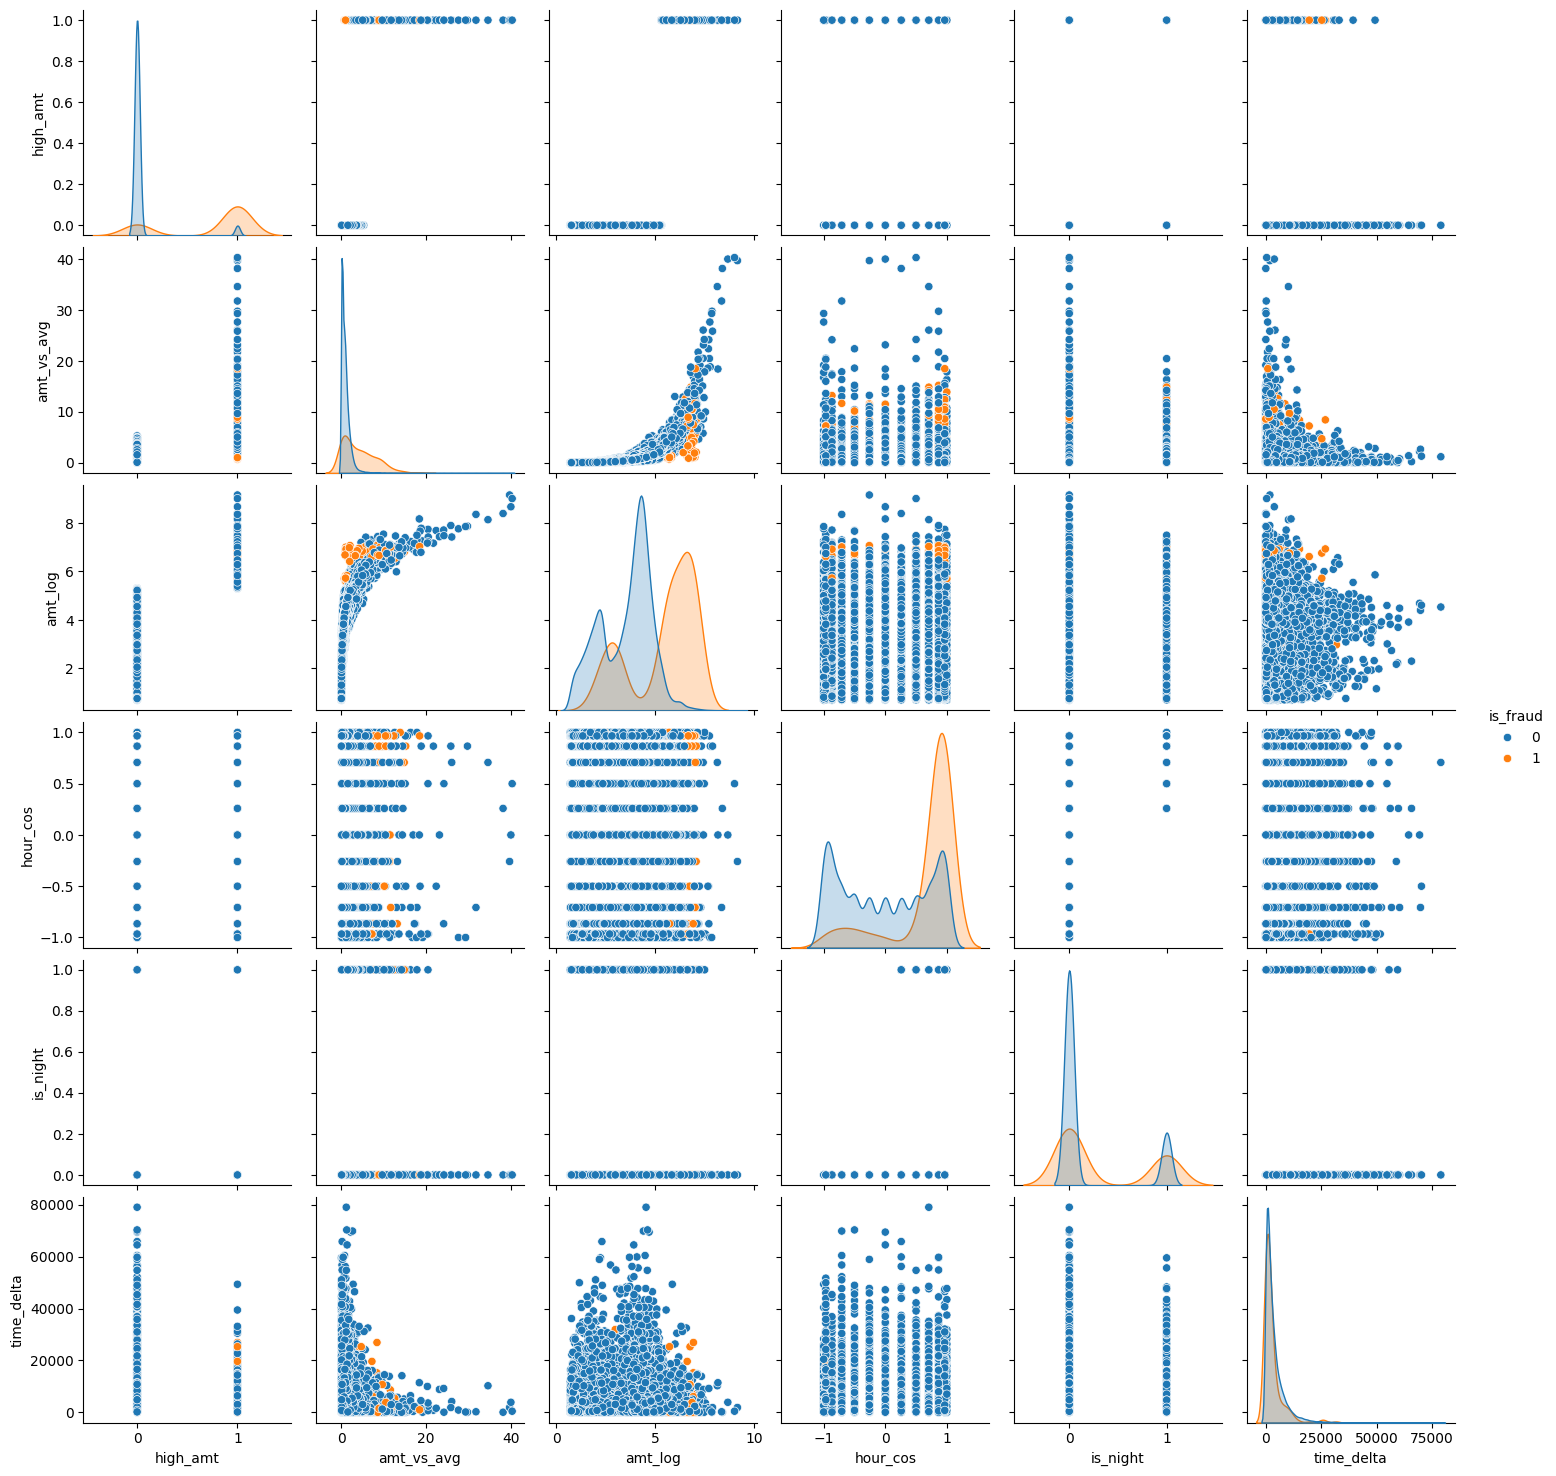

In [56]:
# Pair plot the top 6 numeric features with 'is_fraud' in hue
sns.pairplot(df[top_features], hue='is_fraud', diag_kind="kde", diag_kws=dict(common_norm=False))
plt.show()


In [58]:
# Save cleaned dataset
df.to_csv("cleaned_data_ccf.csv", index=False)

### MODELING    

Several models are built to predict fraudulent transactions. These are in separate notebooks.